# Dialogue Generation in Hinglish


In [1]:
import torch
import pandas as pd 
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
DROPOUT = 0.3

cuda


In [2]:
from datasets import load_dataset
ds = load_dataset("festvox/cmu_hinglish_dog")
print(ds["train"][0]["translation"])

c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'en': 'hi', 'hi_en': 'hi'}


In [3]:
print(ds["train"].features)
print(ds["train"][0])

{'date': Value('string'), 'docIdx': Value('int64'), 'translation': Translation(languages=['en', 'hi_en']), 'uid': Value('string'), 'utcTimestamp': Value('string'), 'rating': Value('int64'), 'status': Value('int64'), 'uid1LogInTime': Value('string'), 'uid1LogOutTime': Value('string'), 'uid1response': {'response': List(Value('int64')), 'type': Value('string')}, 'uid2response': {'response': List(Value('int64')), 'type': Value('string')}, 'user2_id': Value('string'), 'whoSawDoc': List(Value('string')), 'wikiDocumentIdx': Value('int64')}
{'date': '2018-03-16T20:49:27.955Z', 'docIdx': 0, 'translation': {'en': 'hi', 'hi_en': 'hi'}, 'uid': 'user1', 'utcTimestamp': '2018-03-16T20:49:39.626Z', 'rating': 2, 'status': 1, 'uid1LogInTime': '2018-03-16T20:49:27.955Z', 'uid1LogOutTime': '2018-03-16T21:03:06.699Z', 'uid1response': {'response': [1, 2, 3, 4], 'type': 'finish'}, 'uid2response': {'response': [1, 4], 'type': 'finish'}, 'user2_id': 'USR1533', 'whoSawDoc': ['user2'], 'wikiDocumentIdx': 14}


In [4]:
examples = []
data = ds["train"]

current_doc = None
history = []

for row in data:
    doc = row["docIdx"]

    # New conversation
    if doc != current_doc:
        history = []
        current_doc = doc

    target = row["translation"]["hi_en"]

    # Only create an example if we have previous context
    if len(history) > 0:
        examples.append({
            "history": " <eot> ".join(history),
            "target": target,
            "wikiDocumentIdx": row["wikiDocumentIdx"]
        })

    history.append(target)

print("Number of examples:", len(examples))
print("\nHISTORY:")
print(examples[10]["history"])
print("\nTARGET:")
print(examples[10]["target"])

Number of examples: 7226

HISTORY:
hi <eot> tumne konsi movie dekhi <eot> hello tum kaise ho? Kya tumne Batman Begins ke bare mein suna hai? Kya great movie hai! <eot> nahi aur batao <eot> ye kis bare mein hai <eot> Isme Christian Bale, Michael Caine, and Liam Neeson starred hain. Great cast hain na? <eot> han <eot> it is <eot> movie kis baare mein hai <eot> Ye kafi had tak Batman film franchise ka reboot hai nayi origin story ke saath. Christian Bale Batman play kar raha hai <eot> sahi

TARGET:
movie kitni lambi hai


### Dual Encoders
We will use two encoders as one will judge the context of the conversation through previous questions, answers and topics, the other one will generate words based on factual information depending on the question asked
There will be `DialogueEncoder` and `DocumentEncoder`


In [5]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class DialogueEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=PAD
        )

        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )

    def forward(self, src):

        embedded = self.dropout(
            self.embedding(src)
        )

        # Ignore <pad> positions so the final hidden/cell state comes from the
        # last real token instead of from a long run of padding
        lengths = (src != PAD).sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(
            embedded,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        packed_outputs, (hidden, cell) = self.lstm(packed)

        outputs, _ = pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=src.size(1)
        )

        return outputs, hidden, cell

In [6]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class DocumentEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=PAD
        )

        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )

    def forward(self, src):

        embedded = self.dropout(
            self.embedding(src)
        )

        # Ignore <pad> positions so the final hidden/cell state comes from the
        # last real token instead of from a long run of padding
        lengths = (src != PAD).sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(
            embedded,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        packed_outputs, (hidden, cell) = self.lstm(packed)

        outputs, _ = pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=src.size(1)
        )

        return outputs, hidden, cell

In [7]:
class LuongAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_hidden, encoder_outputs, mask=None):

        decoder_hidden = decoder_hidden.unsqueeze(1)

        scores = torch.bmm( #dot product of decoder hidden state and encoder hidden state
            encoder_outputs,
            decoder_hidden.transpose(1, 2)
        )

        scores = scores.squeeze(2)

        # Scale the dot products so the softmax doesn't saturate with large hidden sizes
        scores = scores / (encoder_outputs.size(-1) ** 0.5)

        # Never attend to <pad> positions
        if mask is not None:
            scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)

        attention = torch.softmax(scores, dim=1)

        return attention

The decoder is fed with hidden and cell states from dialogue encoder and not document encoder as the conversation is decided by the conversational state while document is accessed through attention while generating each response

In [8]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        emb_dim,
        hid_dim,
        n_layers,
        dropout
    ):
        super().__init__()

        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=PAD
        )

        self.dropout = nn.Dropout(dropout)

        # Two separate Luong attention mechanisms
        self.dialogue_attention = LuongAttention()
        self.document_attention = LuongAttention()

        # Input to LSTM:
        # embedding + dialogue context + document context
        self.lstm = nn.LSTM(
            emb_dim + 2 * hid_dim,
            hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            hid_dim + 2 * hid_dim,
            output_dim
        )

    def forward(
        self,
        input,
        hidden,
        cell,
        dialogue_outputs,
        document_outputs,
        dialogue_mask=None,
        document_mask=None
    ):
        
        input = input.unsqueeze(1)

        embedded = self.dropout(
            self.embedding(input)
        )

        decoder_hidden = hidden[-1]

        # Attention over dialogue
        dialogue_attn = self.dialogue_attention(
            decoder_hidden,
            dialogue_outputs,
            dialogue_mask
        )

        # Attention over document
        document_attn = self.document_attention(
            decoder_hidden,
            document_outputs,
            document_mask
        )

        dialogue_context = torch.bmm(
            dialogue_attn.unsqueeze(1),
            dialogue_outputs
        )

        document_context = torch.bmm(
            document_attn.unsqueeze(1),
            document_outputs
        )

        # Combine both contexts with word embedding
        lstm_input = torch.cat(
            (
                embedded,
                dialogue_context,
                document_context
            ),
            dim=2
        )

        # Decoder LSTM
        output, (hidden, cell) = self.lstm(
            lstm_input,
            (hidden, cell)
        )

        # Remove sequence dimension
        output = output.squeeze(1)
        dialogue_context = dialogue_context.squeeze(1)
        document_context = document_context.squeeze(1)

        # Predict next token
        # (dropout on the combined features helps against overfitting on small data)
        prediction = self.fc_out(
            self.dropout(
                torch.cat(
                    (
                        output,
                        dialogue_context,
                        document_context
                    ),
                    dim=1
                )
            )
        )

        return prediction, hidden, cell

In [9]:
class Generator(nn.Module):
    def __init__(
        self,
        dialogue_encoder,
        document_encoder,
        decoder,
        device
    ):
        super().__init__()

        self.dialogue_encoder = dialogue_encoder
        self.document_encoder = document_encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        dialogue,
        document,
        target,
        teacher_forcing_ratio=0.5
    ):
        batch_size = target.shape[0]
        target_len = target.shape[1]
        target_vocab_size = self.decoder.output_dim

        # Store predictions
        outputs = torch.zeros(
            batch_size,
            target_len,
            target_vocab_size,
            device=self.device
        )

        # Masks so attention ignores <pad> positions
        dialogue_mask = dialogue != PAD
        document_mask = document != PAD

        # Encode dialogue
        dialogue_outputs, dialogue_hidden, dialogue_cell = \
            self.dialogue_encoder(dialogue)

        # Encode document
        document_outputs, _, _ = \
            self.document_encoder(document)

        # Start decoder with dialogue encoder's final state
        hidden = dialogue_hidden
        cell = dialogue_cell

        # First input is <sos>
        input = target[:, 0]

        for t in range(1, target_len):

            output, hidden, cell = self.decoder(
                input,
                hidden,
                cell,
                dialogue_outputs,
                document_outputs,
                dialogue_mask,
                document_mask
            )

            outputs[:, t, :] = output

            # Teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio

            top1 = output.argmax(1)

            input = target[:, t] if teacher_force else top1

        return outputs

In [10]:
from collections import Counter
import re

data = ds["train"]

# Extract Hinglish text
texts = [
    row["translation"]["hi_en"]
    for row in data
]

# Special tokens
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

SPECIAL_TOKENS = [
    PAD_TOKEN,
    UNK_TOKEN,
    SOS_TOKEN,
    EOS_TOKEN
]

# Simple whitespace tokenizer
# (punctuation is split from words, so "ho?" becomes "ho" + "?" and the vocabulary is far less sparse)
def tokenize(text):
    return re.findall(r"<eot>|\w+(?:'\w+)?|[^\w\s]", text.lower())

# Build vocabulary
counter = Counter()

for text in texts:
    counter.update(tokenize(text))

# Keep words that occur at least twice
MIN_FREQ = 2

vocab = SPECIAL_TOKENS.copy()

for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab.append(word)

# Word → index
stoi = {
    word: idx
    for idx, word in enumerate(vocab)
}

# Index → word
itos = {
    idx: word
    for word, idx in stoi.items()
}

PAD = stoi[PAD_TOKEN]
UNK = stoi[UNK_TOKEN]
SOS = stoi[SOS_TOKEN]
EOS = stoi[EOS_TOKEN]

OUTPUT_DIM = len(vocab)

print("Vocabulary size:", OUTPUT_DIM)
print("PAD:", PAD)
print("UNK:", UNK)
print("SOS:", SOS)
print("EOS:", EOS)

Vocabulary size: 4810
PAD: 0
UNK: 1
SOS: 2
EOS: 3


Now we tokenize the hinglish vocabulary

In [11]:
def numericalize(text):
    tokens = tokenize(text)

    # Add <sos> and <eos>
    tokens = [SOS_TOKEN] + tokens + [EOS_TOKEN]

    # Convert words → integer IDs
    ids = [
        stoi.get(token, UNK)
        for token in tokens
    ]

    return ids


sample = data[0]["translation"]["hi_en"]

print("Text:")
print(sample)

print("\nToken IDs:")
print(numericalize(sample))

Text:
hi

Token IDs:
[2, 4, 3]


In [12]:
examples = []

history = []
previous_doc = None

for row in data:

    # Reset history when the Wikipedia document changes
    # Conversations on the same document must not leak into each other either
    conversation = (row["wikiDocumentIdx"], row["user2_id"], row["uid1LogInTime"])

    if previous_doc is not None and conversation != previous_doc:
        history = []

    target = row["translation"]["hi_en"]

    if history:
        examples.append({
            "dialogue": " <eot> ".join(history),
            "target": target,
            "wikiDocumentIdx": row["wikiDocumentIdx"],
            "docIdx": row["docIdx"]
        })

    history.append(target)

    previous_doc = conversation

In [13]:
import os
import json

repo_dir = "cmu_dog_original"
wiki_dir = os.path.join(repo_dir, "WikiData")

# Build wiki document lookup
wiki_documents = {}

for filename in os.listdir(wiki_dir):

    if not filename.endswith(".json"):
        continue

    filepath = os.path.join(wiki_dir, filename)

    with open(filepath, "r", encoding="utf-8") as f:
        doc = json.load(f)

    wiki_id = doc["wikiDocumentIdx"]
    wiki_documents[wiki_id] = doc


# Convert a document section into plain text
def flatten_section(section):

    if isinstance(section, dict):

        parts = []

        for key, value in section.items():

            if isinstance(value, list):
                value = " ".join(str(x) for x in value)
            else:
                value = str(value)

            parts.append(f"{key}: {value}")

        return " ".join(parts)

    return str(section)


print("Wiki documents:", len(wiki_documents))
print("Document IDs:", sorted(wiki_documents.keys()))

Wiki documents: 30
Document IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [14]:
for example in examples:
    wiki_id = example["wikiDocumentIdx"]
    section_id = str(example["docIdx"])

    section = wiki_documents[wiki_id][section_id]

    example["document"] = flatten_section(section)

# Verify
print("Keys:", examples[0].keys())
print("\nDocument:")
print(examples[0]["document"][:500])

Keys: dict_keys(['dialogue', 'target', 'wikiDocumentIdx', 'docIdx', 'document'])

Document:
cast: Christian Bale as Bruce Wayne / Batman Michael Caine as Alfred Pennyworth Liam Neeson as Henri Ducard / Ra's al Ghul Katie Holmes as Rachel Dawes Gary Oldman as James Gordon critical_response: being both comic-book archetypes and real people comfortably mix the tormented drama and revenge motifs with light hearted gags and comic book allusions,'s who sign up to make them, have no evident motive beyond their own aggrandizement. hype about exploring Batman's damaged psyche both the menace an


In [15]:
from torch.utils.data import Dataset, DataLoader, Sampler

class DialogueDataset(Dataset):
    def __init__(
        self,
        examples,
        max_dialogue_len=256,
        max_document_len=256,
        max_target_len=64
    ):
        self.examples = examples

        self.max_dialogue_len = max_dialogue_len
        self.max_document_len = max_document_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        example = self.examples[idx]

        dialogue = numericalize(example["dialogue"])
        document = numericalize(example["document"])
        target = numericalize(example["target"])

        # Keep the most recent dialogue context
        dialogue = dialogue[-self.max_dialogue_len:]

        # Keep the beginning of the document
        document = document[:self.max_document_len]

        # Limit response length
        # (keep <eos> on truncated targets so the model still learns to stop)
        if len(target) > self.max_target_len:
            target = target[:self.max_target_len - 1] + [EOS]

        return {
            "dialogue": torch.tensor(dialogue, dtype=torch.long),
            "document": torch.tensor(document, dtype=torch.long),
            "target": torch.tensor(target, dtype=torch.long)
        }


train_dataset = DialogueDataset(examples)

print("Dataset size:", len(train_dataset))

sample = train_dataset[0]

print("Dialogue:", len(sample["dialogue"]))
print("Document:", len(sample["document"]))
print("Target:", len(sample["target"]))

Dataset size: 7803
Dialogue: 3
Document: 249
Target: 6


In [16]:
from huggingface_hub import hf_hub_download

zip_path = hf_hub_download(
    repo_id="festvox/cmu_hinglish_dog",
    filename="data-english.zip",
    repo_type="dataset"
)

print("Downloaded to:", zip_path)

Downloaded to: C:\Users\shrey\.cache\huggingface\hub\datasets--festvox--cmu_hinglish_dog\snapshots\19796c6fb32020154cb2745d48704fa73e29b17d\data-english.zip


In [17]:
import subprocess
import os

repo_dir = "cmu_dog_original"

result = subprocess.run(
    [
        "git",
        "clone",
        "--depth", "1",
        "https://github.com/festvox/datasets-CMU_DoG.git",
        repo_dir
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)
print("Done:", os.path.exists(os.path.join(repo_dir, "WikiData")))


fatal: destination path 'cmu_dog_original' already exists and is not an empty directory.

Done: True


In [18]:
wiki_documents = {}

for filename in os.listdir(wiki_dir):

    if not filename.endswith(".json"):
        continue

    filepath = os.path.join(wiki_dir, filename)

    with open(filepath, "r", encoding="utf-8") as f:
        doc = json.load(f)

    wiki_id = doc["wikiDocumentIdx"]

    wiki_documents[wiki_id] = doc

print("Number of documents:", len(wiki_documents))

# Check document 14
print("\nDocument 14 sections:")
print(wiki_documents[14].keys())

Number of documents: 30

Document 14 sections:
dict_keys(['0', '1', '2', '3', 'wikiDocumentIdx'])


In [19]:
def flatten_section(section):
    # Section 0 is a dictionary containing lists/strings
    if isinstance(section, dict):
        parts = []

        for key, value in section.items():
            if isinstance(value, list):
                value = " ".join(str(x) for x in value)
            else:
                value = str(value)

            parts.append(f"{key}: {value}")

        return " ".join(parts)

    # Sections 1, 2, 3 are already strings
    return str(section)

### Bucket Batching
Again as done in previous tasks we should create batches of similar lengths to avoid excessive padding


In [20]:
import numpy as np
from torch.utils.data import Sampler

class BucketBatchSampler(Sampler):
    def __init__(
        self,
        dataset,
        batch_size,
        shuffle=True,
        bucket_size_multiplier=50
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.bucket_size = batch_size * bucket_size_multiplier

        # Length used for bucketing
        self.lengths = []

        # (the document is almost always at max length, so bucket by target then dialogue length:
        #  the decoder loop runs for the longest target in the batch)
        for example in dataset:
            length = (
                len(example["target"]),
                len(example["dialogue"])
            )
            self.lengths.append(length)

    def __iter__(self):

        indices = np.arange(len(self.dataset))

        if self.shuffle:
            np.random.shuffle(indices)

        batches = []

        # Split into large chunks
        for start in range(0, len(indices), self.bucket_size):

            chunk = indices[start:start + self.bucket_size]

            # Sort similar-length examples together
            chunk = sorted(
                chunk,
                key=lambda idx: self.lengths[idx]
            )

            # Create batches
            for i in range(0, len(chunk), self.batch_size):
                batch = chunk[i:i + self.batch_size]

                # Keep the last partial batch when not shuffling (validation/test)
                # so no examples are silently dropped
                if len(batch) == self.batch_size or not self.shuffle:
                    batches.append(batch)

        # Shuffle the batches themselves
        if self.shuffle:
            np.random.shuffle(batches)

        for batch in batches:
            yield batch

    def __len__(self):
        if not self.shuffle:
            return -(-len(self.dataset) // self.batch_size)

        return len(self.dataset) // self.batch_size

In [21]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    dialogues = [item["dialogue"] for item in batch]
    documents = [item["document"] for item in batch]
    targets = [item["target"] for item in batch]

    # Pad only to the longest sequence in THIS batch
    dialogues = pad_sequence(
        dialogues,
        batch_first=True,
        padding_value=PAD
    )

    documents = pad_sequence(
        documents,
        batch_first=True,
        padding_value=PAD
    )

    targets = pad_sequence(
        targets,
        batch_first=True,
        padding_value=PAD
    )

    return dialogues, documents, targets

In [22]:
BATCH_SIZE = 32
from torch.utils.data import DataLoader

batch_sampler = BucketBatchSampler(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    collate_fn=collate_fn
)

# Test one batch
dialogues, documents, targets = next(iter(train_loader))

print("Dialogue:", dialogues.shape)
print("Document:", documents.shape)
print("Target:", targets.shape)

Dialogue: torch.Size([32, 91])
Document: torch.Size([32, 256])
Target: torch.Size([32, 8])


In [23]:
from collections import Counter

counter = Counter()

# Count every utterance once and every Wikipedia section once.
# (Counting over `examples` repeated each document for every one of its examples,
#  so every document word looked frequent and the vocabulary exploded.)
for text in texts:
    counter.update(tokenize(text))

for wiki_doc in wiki_documents.values():
    for key, section in wiki_doc.items():
        if key == "wikiDocumentIdx":
            continue
        counter.update(tokenize(flatten_section(section)))

MIN_FREQ = 2

vocab = SPECIAL_TOKENS.copy()

for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab.append(word)

stoi = {
    word: idx
    for idx, word in enumerate(vocab)
}

itos = {
    idx: word
    for word, idx in stoi.items()
}

PAD = stoi[PAD_TOKEN]
UNK = stoi[UNK_TOKEN]
SOS = stoi[SOS_TOKEN]
EOS = stoi[EOS_TOKEN]

INPUT_DIM = len(vocab)
OUTPUT_DIM = len(vocab)

print("Vocabulary size:", INPUT_DIM)
print("PAD:", PAD)
print("UNK:", UNK)
print("SOS:", SOS)
print("EOS:", EOS)

Vocabulary size: 6347
PAD: 0
UNK: 1
SOS: 2
EOS: 3


In [24]:
train_dataset = DialogueDataset(examples)

print("Dataset size:", len(train_dataset))

sample = train_dataset[0]

dialogue_encoder = DialogueEncoder(
    vocab_size=INPUT_DIM,
    emb_dim=EMB_DIM,
    hid_dim=HID_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
)

document_encoder = DocumentEncoder(
    vocab_size=INPUT_DIM,
    emb_dim=EMB_DIM,
    hid_dim=HID_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
)

decoder = Decoder(
    output_dim=OUTPUT_DIM,
    emb_dim=EMB_DIM,
    hid_dim=HID_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
)

# Share one embedding table between both encoders and the decoder:
# ~3x fewer embedding parameters, which matters with this little training data
document_encoder.embedding = dialogue_encoder.embedding
decoder.embedding = dialogue_encoder.embedding

model = Generator(
    dialogue_encoder,
    document_encoder,
    decoder,
    device
).to(device)

Dataset size: 7803


In [25]:
from tqdm.auto import tqdm

def train(model, loader, optimizer, criterion, clip=1.0, teacher_forcing_ratio=0.9):

    model.train()
    epoch_loss = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=True
    )

    for dialogues, documents, targets in progress_bar:

        dialogues = dialogues.to(device)
        documents = documents.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        output = model(
            dialogues,
            documents,
            targets,
            teacher_forcing_ratio=teacher_forcing_ratio
        )

        output_dim = output.shape[-1]

        output = output[:, 1:].reshape(-1, output_dim)
        targets = targets[:, 1:].reshape(-1)

        loss = criterion(output, targets)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

        # Show running loss on the progress bar
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return epoch_loss / len(loader)

In [26]:
val_data = ds["validation"]

val_examples = []

history = []
previous_doc = None

for row in val_data:

    # Reset dialogue history when the Wikipedia document changes
    # Conversations on the same document must not leak into each other either
    conversation = (row["wikiDocumentIdx"], row["user2_id"], row["uid1LogInTime"])

    if previous_doc is not None and conversation != previous_doc:
        history = []

    target = row["translation"]["hi_en"]

    if history:

        wiki_id = row["wikiDocumentIdx"]
        section_id = str(row["docIdx"])

        val_examples.append({
            "dialogue": " <eot> ".join(history),
            "document": flatten_section(
                wiki_documents[wiki_id][section_id]
            ),
            "target": target,
            "wikiDocumentIdx": wiki_id,
            "docIdx": row["docIdx"]
        })

    history.append(target)

    previous_doc = conversation


val_dataset = DialogueDataset(
    val_examples,
    max_dialogue_len=256,
    max_document_len=256,
    max_target_len=64
)

In [27]:
val_batch_sampler = BucketBatchSampler(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    bucket_size_multiplier=50
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_batch_sampler,
    collate_fn=collate_fn
)

print("Validation batches:", len(val_loader))

dialogues, documents, targets = next(iter(val_loader))

print("Dialogue:", dialogues.shape)
print("Document:", documents.shape)
print("Target:", targets.shape)

Validation batches: 29
Dialogue: torch.Size([32, 256])
Document: torch.Size([32, 256])
Target: torch.Size([32, 4])


In [28]:
from tqdm.auto import tqdm

def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=True
    )

    with torch.no_grad():

        for dialogues, documents, targets in progress_bar:

            dialogues = dialogues.to(device)
            documents = documents.to(device)
            targets = targets.to(device)

            output = model(
                dialogues,
                documents,
                targets,
                # Teacher forcing, so validation loss is the true per-token loss and is comparable across epochs
                teacher_forcing_ratio=1.0
            )

            output_dim = output.shape[-1]

            output = output[:, 1:].reshape(-1, output_dim)
            targets = targets[:, 1:].reshape(-1)

            loss = criterion(output, targets)

            epoch_loss += loss.item()

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    return epoch_loss / len(loader)

In [30]:
import copy

epochs = 3
train_losses = []
val_losses = []

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

train_criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

best_val_loss = float("inf")
best_state = None
patience = 3
bad_epochs = 0

for epoch in range(epochs):

    print(f"\nEpoch {epoch + 1}/{epochs}")

    train_loss = train(
        model,
        train_loader,
        optimizer,
        train_criterion,
        clip=1.0
    )

    val_loss = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, "best_model.pt")
        bad_epochs = 0
    else:
        bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping: validation loss stopped improving")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model (Val Loss: {best_val_loss:.4f})")



Epoch 1/3


Validation: 100%|██████████| 29/29 [00:01<00:00, 16.33it/s, loss=5.6723]


Train Loss: 6.1583
Val Loss:   5.2970

Epoch 2/3


Validation: 100%|██████████| 29/29 [00:02<00:00, 13.98it/s, loss=5.3760]


Train Loss: 5.7834
Val Loss:   5.0314

Epoch 3/3


Validation: 100%|██████████| 29/29 [00:01<00:00, 16.73it/s, loss=5.2590]


Train Loss: 5.5709
Val Loss:   4.8952
Loaded best model (Val Loss: 4.8952)


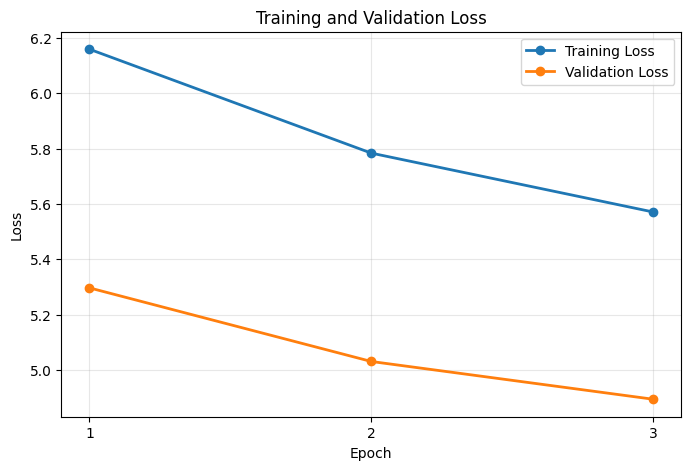

In [31]:
epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [32]:
test_data = ds["test"]

test_examples = []

history = []
previous_doc = None

for row in test_data:

    # Reset history when the Wikipedia document changes
    # Conversations on the same document must not leak into each other either
    conversation = (row["wikiDocumentIdx"], row["user2_id"], row["uid1LogInTime"])

    if previous_doc is not None and conversation != previous_doc:
        history = []

    target = row["translation"]["hi_en"]

    if history:

        wiki_id = row["wikiDocumentIdx"]
        section_id = str(row["docIdx"])

        test_examples.append({
            "dialogue": " <eot> ".join(history),
            "document": flatten_section(
                wiki_documents[wiki_id][section_id]
            ),
            "target": target,
            "wikiDocumentIdx": wiki_id,
            "docIdx": row["docIdx"]
        })

    history.append(target)
    previous_doc = conversation


test_dataset = DialogueDataset(
    test_examples,
    max_dialogue_len=256,
    max_document_len=256,
    max_target_len=64
)

print("Test examples:", len(test_dataset))

sample = test_dataset[0]

print("Dialogue length:", len(sample["dialogue"]))
print("Document length:", len(sample["document"]))
print("Target length:", len(sample["target"]))

Test examples: 928
Dialogue length: 3
Document length: 256
Target length: 40


In [33]:
test_batch_sampler = BucketBatchSampler(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    bucket_size_multiplier=50
)

test_loader = DataLoader(
    test_dataset,
    batch_sampler=test_batch_sampler,
    collate_fn=collate_fn
)

In [34]:
test_loss = evaluate(
    model,
    test_loader,
    criterion
)

print(f"\nTest Loss: {test_loss:.4f}")

Validation: 100%|██████████| 29/29 [00:02<00:00, 14.12it/s, loss=5.3710]


Test Loss: 4.8791


### Hinglish Generation

In [35]:
def generate_response(model, dialogue, document, max_len=64, min_len=2):

    model.eval()

    with torch.no_grad():

        dialogue = dialogue.unsqueeze(0).to(device)
        document = document.unsqueeze(0).to(device)

        dialogue_outputs, hidden, cell = model.dialogue_encoder(dialogue)

        document_outputs, _, _ = model.document_encoder(document)

        # Start with <sos>
        input_token = torch.tensor(
            [SOS],
            dtype=torch.long,
            device=device
        )

        generated_tokens = []

        for _ in range(max_len):

            output, hidden, cell = model.decoder(
                input_token,
                hidden,
                cell,
                dialogue_outputs,
                document_outputs
            )

            logits = output.clone()

            # Never generate <pad>, <sos> or <unk>
            logits[:, PAD] = float("-inf")
            logits[:, SOS] = float("-inf")
            logits[:, UNK] = float("-inf")

            # Don't stop too early
            if len(generated_tokens) < min_len:
                logits[:, EOS] = float("-inf")

            # Don't repeat the previous token ("hai hai hai ...")
            if generated_tokens:
                logits[:, generated_tokens[-1]] = float("-inf")

            # Don't repeat a trigram that was already generated
            if len(generated_tokens) >= 2:
                prefix = generated_tokens[-2:]

                for i in range(len(generated_tokens) - 2):
                    if generated_tokens[i:i + 2] == prefix:
                        logits[:, generated_tokens[i + 2]] = float("-inf")

            # Greedy decoding
            next_token = logits.argmax(1)

            token_id = next_token.item()

            # Stop at <eos>
            if token_id == EOS:
                break

            generated_tokens.append(token_id)

            input_token = next_token

        # Convert IDs back to words
        words = [
            itos[token_id]
            for token_id in generated_tokens
        ]

        return " ".join(words)

In [36]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm

references = []
hypotheses = []

model.eval()

for i in tqdm(range(len(test_dataset)), desc="Generating test responses"):

    sample = test_dataset[i]

    generated = generate_response(
        model,
        sample["dialogue"],
        sample["document"]
    )

    # Target tokens
    target_tokens = [
        itos[token_id]
        for token_id in sample["target"].tolist()
        if token_id not in [PAD, SOS, EOS]
    ]

    generated_tokens = generated.split()

    if len(generated_tokens) > 0:
        references.append([target_tokens])
        hypotheses.append(generated_tokens)

smoothie = SmoothingFunction().method1

bleu = corpus_bleu(
    references,
    hypotheses,
    smoothing_function=smoothie
)

print(f"Test BLEU: {bleu:.4f}")

Generating test responses: 100%|██████████| 928/928 [00:27<00:00, 33.35it/s]

Test BLEU: 0.0004


In [37]:
for n, w in [(1, (1, 0, 0, 0)), (2, (.5, .5, 0, 0)), (4, (.25, .25, .25, .25))]:
    print(f"BLEU-{n}: {corpus_bleu(references, hypotheses, weights=w, smoothing_function=smoothie):.4f}")

ref_tokens = [t for r in references for t in r[0]]
print("reference <unk> rate:", sum(t == "<unk>" for t in ref_tokens) / len(ref_tokens))
print("avg generated length:", sum(len(h) for h in hypotheses) / len(hypotheses))

for i in range(0, len(test_dataset), 93):
    s = test_dataset[i]
    print("\nDIALOGUE:", " ".join(itos[t] for t in s["dialogue"].tolist()[-30:]))
    print("REF:     ", " ".join(itos[t] for t in s["target"].tolist() if t not in (PAD, SOS, EOS)))
    print("GEN:     ", generate_response(model, s["dialogue"], s["document"]))

BLEU-1: 0.0175
BLEU-2: 0.0063
BLEU-4: 0.0004
reference <unk> rate: 0.08078125
avg generated length: 4.131465517241379

DIALOGUE: <sos> hi <eos>
REF:      <unk> the <unk> 2012 ki <unk> superhero film hai jo isi naam ki marvel comics superhero team par based hai , marvel studios ne isey produce kiya ha aur <unk> <unk> motion pictures ne isey <unk> kiya hai
GEN:      hi , kya aap

DIALOGUE: thriller hai . <unk> mujhe lagata hai ki <unk> <unk> ka <unk> hai " science fiction " <unk> voh toh thriller aspect hoga , lakin <unk> sci - fi <eos>
REF:      voh toh sach hein yar
GEN:      kya tum movie hai

DIALOGUE: <sos> issi <unk> <unk> hi good day <unk> kiya humlog isko movie bol <unk> <eos>
REF:      <unk> ka movie ke naam superhero hain
GEN:      kya tumne

DIALOGUE: ko kaise apne mom aur family se <unk> kiya <unk> acha movie hein yar . . . mein tho imagine bhi nahi kar sakthi uska mom ka feeling ko <eos>
REF:      mein bhi . . voh tho horrible ho <unk> . . kaise <unk> rahi thi apni family ko